## **변수 EDA**

#데이터 구조 확인

이 데이터가 몇 행 몇 열인지
각 컬럼이 어떤 타입인지
결측치가 있는지
분석 대상인 salary_in_usd가 어떤 분포를 가지는지 확인

In [59]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

print("Ready")

Ready


In [60]:
df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MOMENTUM/project1/ds_salaries.csv')

print("데이터 크기:", df_raw.shape)
display(df_raw.head())

데이터 크기: (607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [61]:
df_raw.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [62]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [63]:
df_raw.isnull().sum()

,0
Unnamed: 0,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0


In [64]:
df = df_raw.copy()

drop_cols = ['Unnamed: 0', 'salary', 'salary_currency']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

print("정리 후 데이터 크기:", df.shape)
display(df.head())

정리 후 데이터 크기: (607, 9)


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L


In [65]:
column_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str),
    'n_unique': [df[col].nunique() for col in df.columns],
    'missing': [df[col].isnull().sum() for col in df.columns]
})

display(column_summary)

,column,dtype,n_unique,missing
work_year,work_year,int64,3,0
experience_level,experience_level,object,4,0
employment_type,employment_type,object,4,0
job_title,job_title,object,50,0
salary_in_usd,salary_in_usd,int64,369,0
employee_residence,employee_residence,object,57,0
remote_ratio,remote_ratio,int64,3,0
company_location,company_location,object,50,0
company_size,company_size,object,3,0


#salary_in_usd 분포 확인

In [66]:
display(df['salary_in_usd'].describe())

print("평균:", df['salary_in_usd'].mean())
print("중앙값:", df['salary_in_usd'].median())
print("최솟값:", df['salary_in_usd'].min())
print("최댓값:", df['salary_in_usd'].max())
print("상위 25% 기준:", df['salary_in_usd'].quantile(0.75))
print("상위 10% 기준:", df['salary_in_usd'].quantile(0.90))

,salary_in_usd
count,607.000000
mean,112297.869852
std,70957.259411
min,2859.000000
25%,62726.000000
50%,101570.000000
75%,150000.000000
max,600000.000000


평균: 112297.86985172982
중앙값: 101570.0
최솟값: 2859
최댓값: 600000
상위 25% 기준: 150000.0
상위 10% 기준: 200000.0


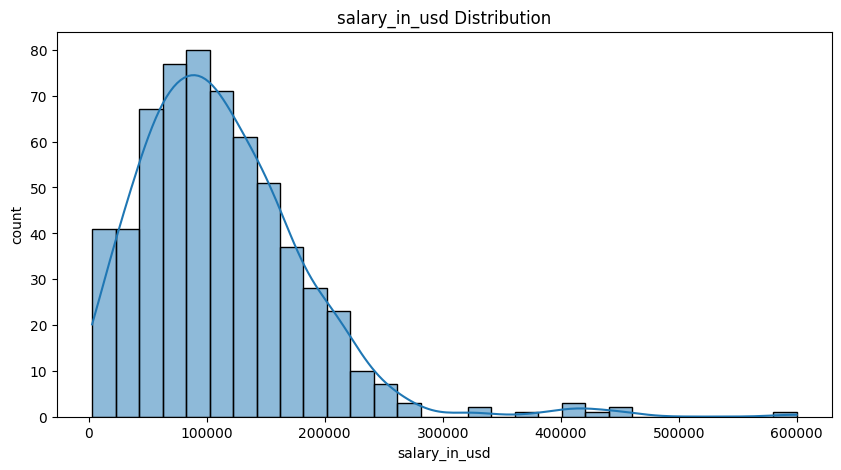

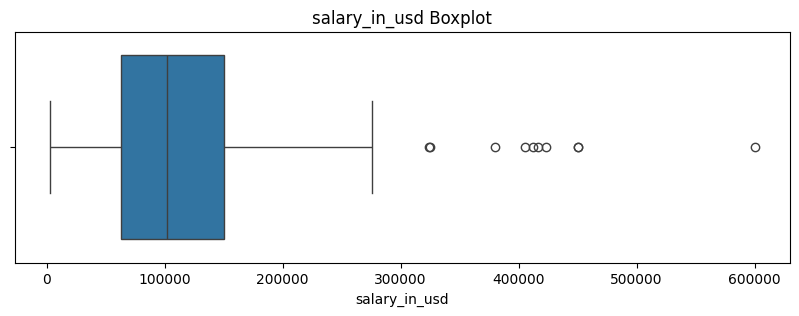

In [67]:
plt.figure(figsize=(10, 5))
sns.histplot(df['salary_in_usd'], bins=30, kde=True)
plt.title('salary_in_usd Distribution')
plt.xlabel('salary_in_usd')
plt.ylabel('count')
plt.show()

plt.figure(figsize=(10, 3))
sns.boxplot(x=df['salary_in_usd'])
plt.title('salary_in_usd Boxplot')
plt.xlabel('salary_in_usd')
plt.show()

# 수치형/범주형 변수

In [68]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("수치형 변수:", numeric_cols)
print("범주형 변수:", categorical_cols)

수치형 변수: ['work_year', 'salary_in_usd', 'remote_ratio']
범주형 변수: ['experience_level', 'employment_type', 'job_title', 'employee_residence', 'company_location', 'company_size']


In [69]:
for col in categorical_cols:
    print(f"===== {col} =====")
    print("고유값 개수:", df[col].nunique())
    display(df[col].value_counts().head(15))
    print()

===== experience_level =====
고유값 개수: 4


,count
experience_level,
SE,280
MI,213
EN,88
EX,26



===== employment_type =====
고유값 개수: 4


,count
employment_type,
FT,588
PT,10
CT,5
FL,4



===== job_title =====
고유값 개수: 50


...

,count
employee_residence,
US,332
GB,44
IN,30
CA,29
DE,25
FR,18
ES,15
GR,13
JP,7



===== company_location =====
고유값 개수: 50


,count
company_location,
US,355
GB,47
CA,30
DE,28
IN,24
FR,15
ES,14
GR,11
JP,6



===== company_size =====
고유값 개수: 3


,count
company_size,
M,326
L,198
S,83


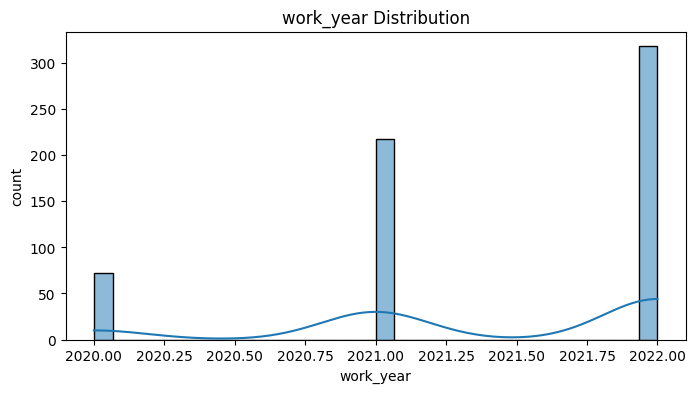

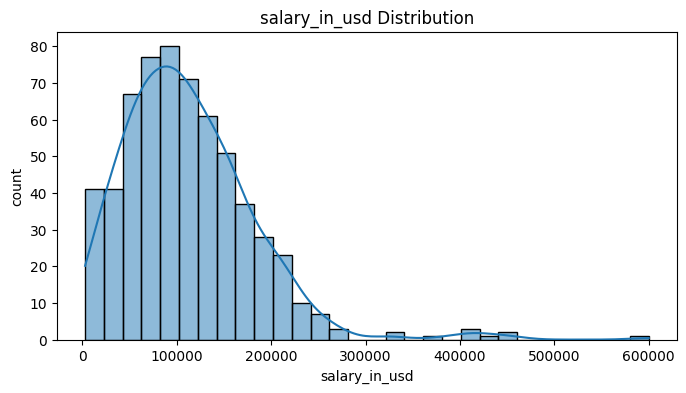

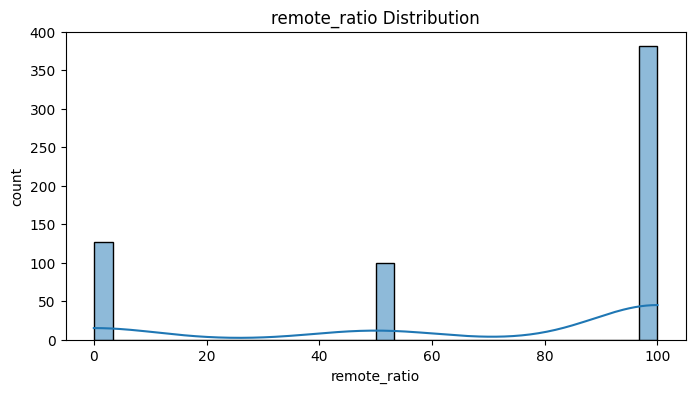

In [70]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

# 변수별 연봉

In [71]:
#연도별 연봉

year_salary = df.groupby('work_year')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
).sort_index()

display(year_salary)

,count,mean,median,min,max
work_year,,,,,
2020,72,95813.000000,75544.0,5707,450000
2021,217,99853.792627,82528.0,2859,600000
2022,318,124522.006289,120000.0,10000,405000


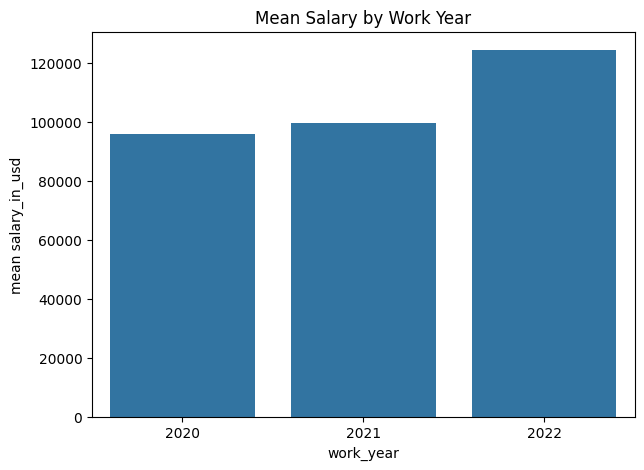

In [72]:
plt.figure(figsize=(7, 5))
sns.barplot(data=year_salary.reset_index(), x='work_year', y='mean')
plt.title('Mean Salary by Work Year')
plt.xlabel('work_year')
plt.ylabel('mean salary_in_usd')
plt.show()

In [73]:
#경력 수준별 연봉

exp_salary = df.groupby('experience_level')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max',

).sort_values('mean',ascending=False)

display(exp_salary)

,count,mean,median,min,max
experience_level,,,,,
EX,26,199392.038462,171437.5,69741,600000
SE,280,138617.292857,135500.0,18907,412000
MI,213,87996.056338,76940.0,2859,450000
EN,88,61643.318182,56500.0,4000,250000


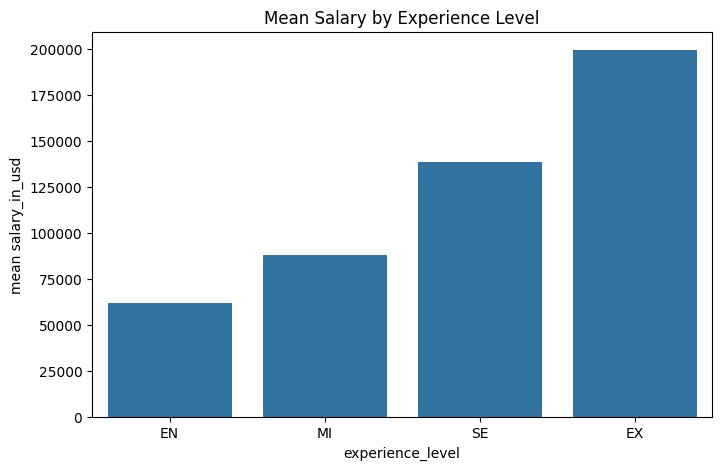

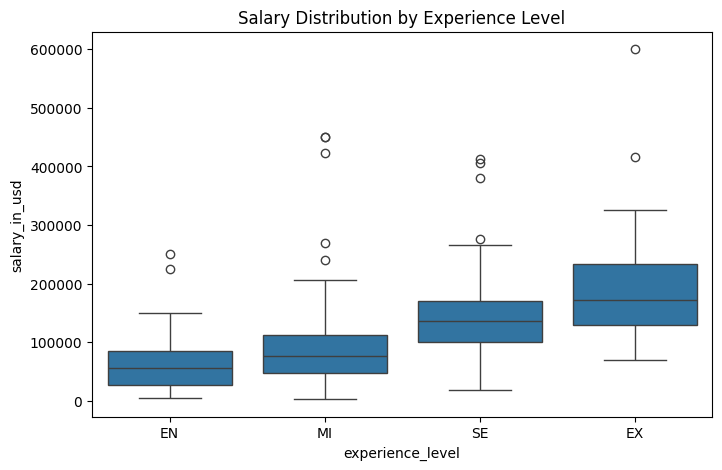

In [74]:
exp_order = ['EN', 'MI', 'SE', 'EX']

plt.figure(figsize=(8, 5))
sns.barplot(data=exp_salary.reset_index(), x='experience_level', y='mean', order=exp_order)
plt.title('Mean Salary by Experience Level')
plt.xlabel('experience_level')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='experience_level', y='salary_in_usd', order=exp_order)
plt.title('Salary Distribution by Experience Level')
plt.xlabel('experience_level')
plt.ylabel('salary_in_usd')
plt.show()

- 경력 수준이 높아질수록 평균과 중앙값이 전반적으로 증가

- EX는 26개밖에 없기 때문에 평균이 일부 고연봉자에 영향을 받을 수 있음. 하지만 중앙값도 높기 때문에, 경력 수준은 연봉 차이를 설명하는 중요한 변수일 가능성이 높음

In [75]:
#고용 형태별 연봉

employment_salary = df.groupby('employment_type')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
).sort_values('mean', ascending=False)

display(employment_salary)

,count,mean,median,min,max
employment_type,,,,,
CT,5,184575.000000,105000.0,31875,416000
FT,588,113468.073129,104196.5,2859,600000
FL,4,48000.000000,40000.0,12000,100000
PT,10,33070.500000,18817.5,5409,100000


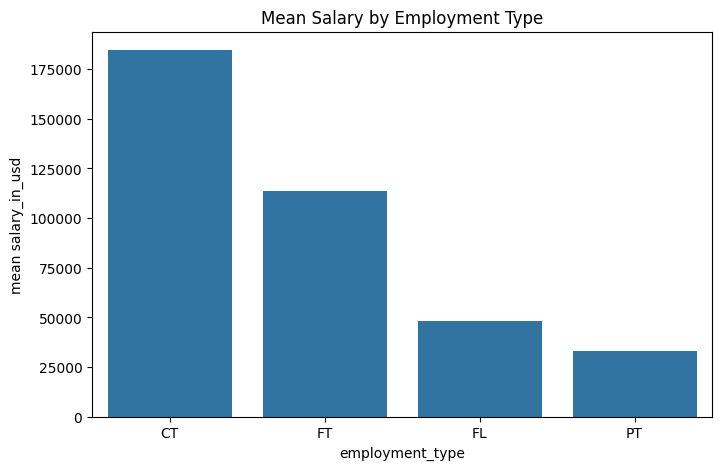

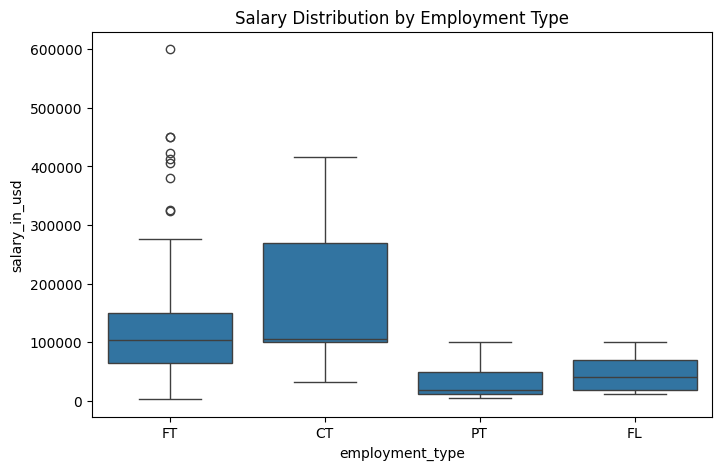

In [76]:
plt.figure(figsize=(8, 5))
sns.barplot(data=employment_salary.reset_index(), x='employment_type', y='mean')
plt.title('Mean Salary by Employment Type')
plt.xlabel('employment_type')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='employment_type', y='salary_in_usd')
plt.title('Salary Distribution by Employment Type')
plt.xlabel('employment_type')
plt.ylabel('salary_in_usd')
plt.show()

- FT가 대부분이면 PT, CT, FL 평균은 표본 수가 적어 불안정할 수 있음

- 겉으로 보면 CT 계약직의 평균 연봉이 가장 높아 보임
하지만 CT는 5개뿐

- 고용 형태는 메인 변수로 쓰기보다는, 고연봉자 조건 조합을 볼 때 참고 변수 정도?

In [77]:
#원격근무 비율별 연봉
remote_salary = df.groupby('remote_ratio')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
).sort_index()

display(remote_salary)

,count,mean,median,min,max
remote_ratio,,,,,
0,127,106354.622047,99000.0,2859,450000
50,99,80823.030303,69999.0,5409,423000
100,381,122457.454068,115000.0,4000,600000


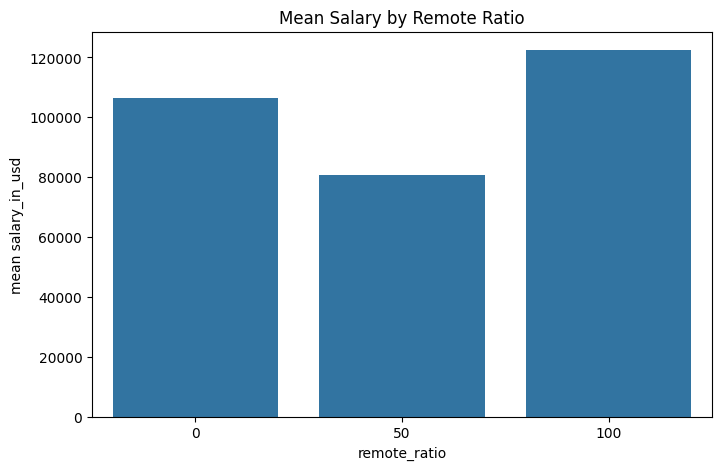

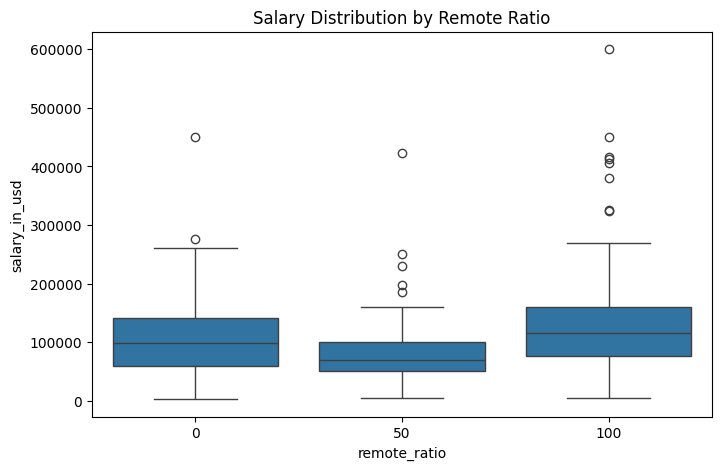

In [78]:
plt.figure(figsize=(8, 5))
sns.barplot(data=remote_salary.reset_index(), x='remote_ratio', y='mean')
plt.title('Mean Salary by Remote Ratio')
plt.xlabel('remote_ratio')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='remote_ratio', y='salary_in_usd')
plt.title('Salary Distribution by Remote Ratio')
plt.xlabel('remote_ratio')
plt.ylabel('salary_in_usd')
plt.show()

- '원격근무를 하면 연봉이 높다' 라고 말하면 위험함

- 왜냐하면 100% 원격근무 그룹 안에 미국 회사나 SE/EX급 인력이 많이 포함되어 있을 수 있음

원래 가설 3
<원격근무 비율이 높을수록 연봉이 높아 보일 수 있지만, 실제 원인은 원격근무가 아니라 미국 회사/고경력자 비중일 수 있다.> 과 연결

원격근무 100% 그룹의 연봉이 가장 높게 나타났지만, 이 차이가 원격근무 자체 때문인지, 미국 회사나 고경력자 비중 때문인지는 추가 확인이 필요

In [79]:
#회사 규모별 연봉

size_salary = df.groupby('company_size')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

display(size_salary)

,count,mean,median,min,max
company_size,,,,,
L,198,119242.994949,100000.0,5882,600000
M,326,116905.466258,113188.0,4000,450000
S,83,77632.674699,65000.0,2859,416000


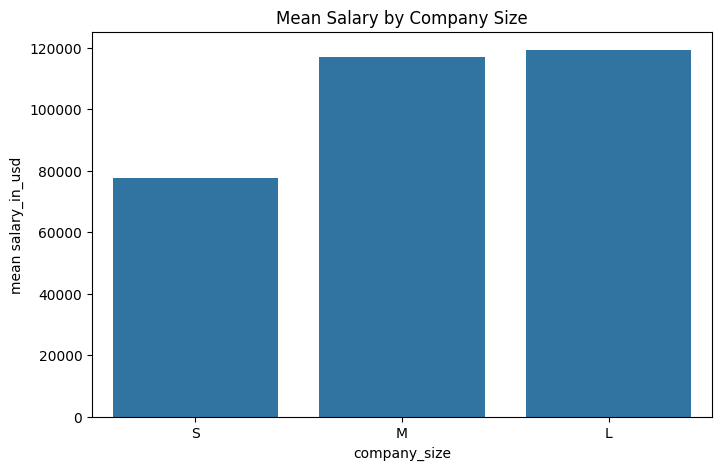

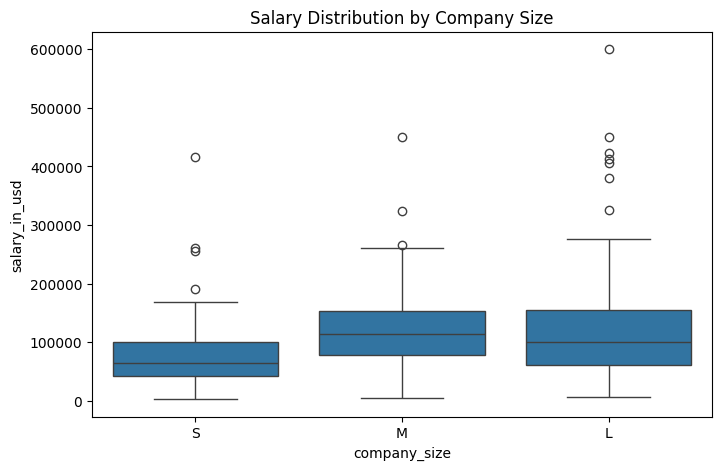

In [80]:
size_order = ['S', 'M', 'L']

plt.figure(figsize=(8, 5))
sns.barplot(data=size_salary.reset_index(), x='company_size', y='mean', order=size_order)
plt.title('Mean Salary by Company Size')
plt.xlabel('company_size')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='company_size', y='salary_in_usd', order=size_order)
plt.title('Salary Distribution by Company Size')
plt.xlabel('company_size')
plt.ylabel('salary_in_usd')
plt.show()

- 소규모 회사 S는 평균과 중앙값이 낮음
- M과 L은 평균은 비슷한데, 중앙값은 오히려 M이 더 높습니다.

단순히 '대기업일수록 연봉이 높다.' 라고 보기 어려움

가설5
<(중)소규모 회사의 임원/전문가 급의 고위직들은 대기업 중급(MI)보다 더 높은 연봉을 받을 수도 있다.> 와 연결

In [81]:
#(상위 10개) 직원 거주 국가별 연봉
top_residences = df['employee_residence'].value_counts().head(10).index
df_top_residences = df[df['employee_residence'].isin(top_residences)]

display(df['employee_residence'].value_counts().head(10))

residence_salary = df_top_residences.groupby('employee_residence')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
).sort_values('mean', ascending=False)

display(residence_salary)

,count
employee_residence,
US,332
GB,44
IN,30
CA,29
DE,25
FR,18
ES,15
GR,13
JP,7


,count,mean,median,min,max
employee_residence,,,,,
US,332,149194.117470,138475.0,25000,600000
JP,7,103537.714286,74000.0,40000,260000
CA,29,97085.310345,85000.0,52000,196979
DE,25,85552.560000,79197.0,15966,173762
GB,44,81403.159091,78526.0,37300,183228
FR,18,59886.611111,57920.0,36643,93427
ES,15,57593.400000,49461.0,10354,130800
GR,13,56331.230769,54957.0,20000,88654
PT,6,42862.500000,53090.0,10000,60757


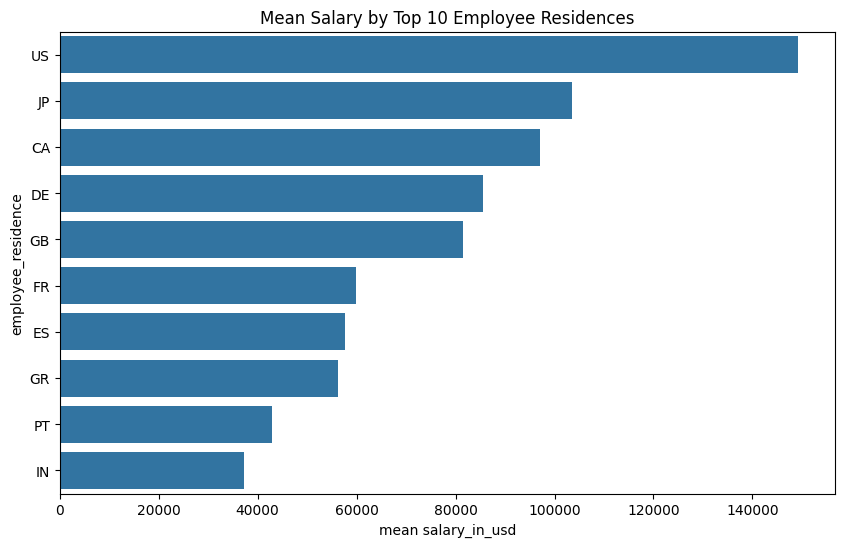

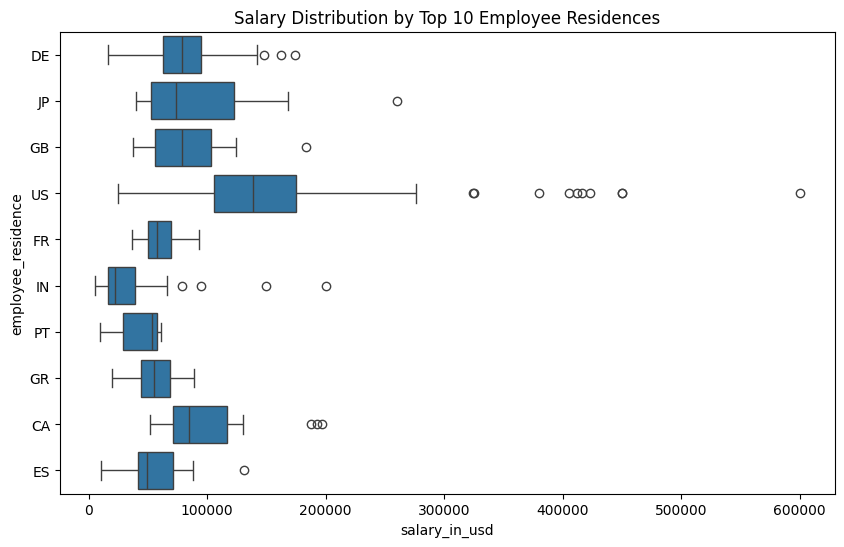

In [82]:
plt.figure(figsize=(10, 6))
sns.barplot(data=residence_salary.reset_index(), y='employee_residence', x='mean')
plt.title('Mean Salary by Top 10 Employee Residences')
plt.xlabel('mean salary_in_usd')
plt.ylabel('employee_residence')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top_residences, y='employee_residence', x='salary_in_usd')
plt.title('Salary Distribution by Top 10 Employee Residences')
plt.xlabel('salary_in_usd')
plt.ylabel('employee_residence')
plt.show()

- 미국 거주자의 평균/중앙값이 높은가?
- 다른 국가들은 표본 수가 충분한가?
- 거주 국가 기준만으로 연봉 차이를 설명할 수 있는가?

In [83]:
#(상위 10개) 회사 위치별 연봉

top_company_locations = df['company_location'].value_counts().head(10).index
df_top_company_locations = df[df['company_location'].isin(top_company_locations)]

display(df['company_location'].value_counts().head(10))

company_location_salary = df_top_company_locations.groupby('company_location')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
).sort_values('mean', ascending=False)

display(company_location_salary)

,count
company_location,
US,355
GB,47
CA,30
DE,28
IN,24
FR,15
ES,14
GR,11
JP,6


,count,mean,median,min,max
company_location,,,,,
US,355,144055.261972,135000.0,5679,600000
JP,6,114127.333333,75682.0,41689,260000
CA,30,99823.733333,81895.5,52000,225000
DE,28,81887.214286,78015.0,15966,173762
GB,47,81583.042553,78526.0,37300,183228
FR,15,63970.666667,56738.0,36643,152000
NL,4,54945.750000,54021.0,42000,69741
ES,14,53060.142857,48371.5,10354,87932
GR,11,52293.090909,49461.0,20000,87932


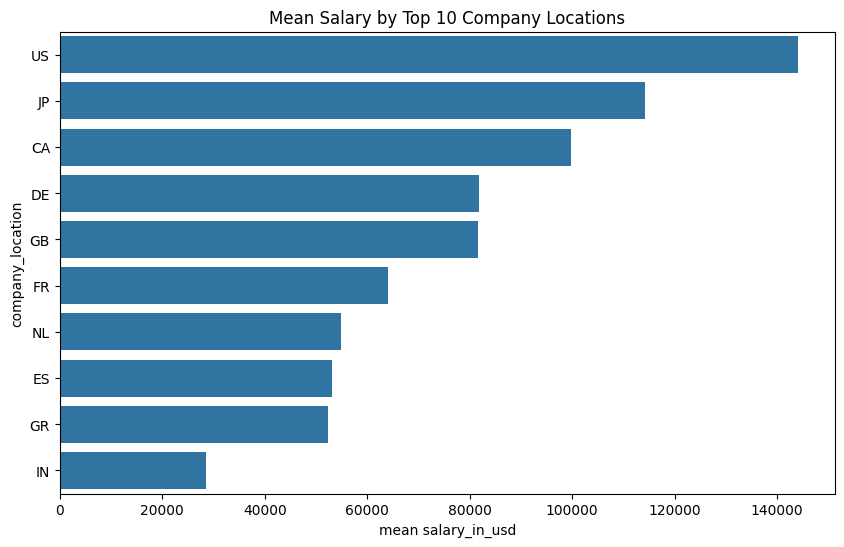

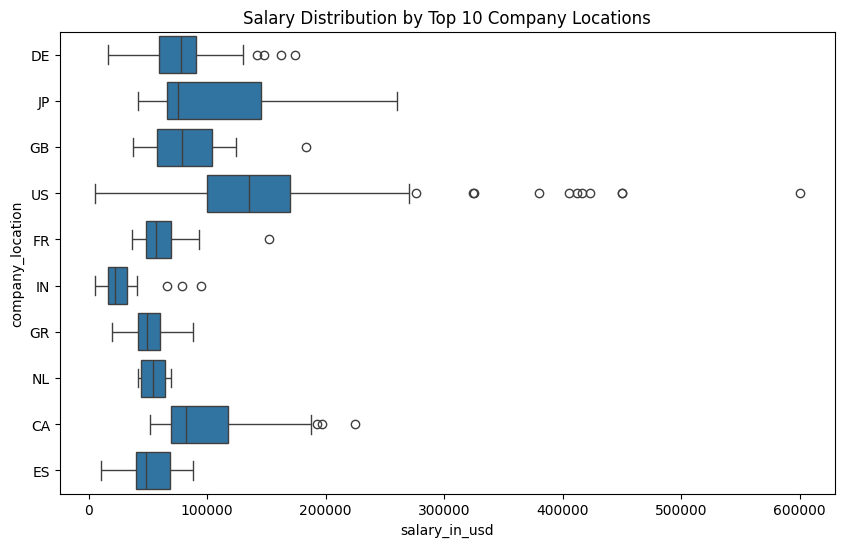

In [84]:
plt.figure(figsize=(10, 6))
sns.barplot(data=company_location_salary.reset_index(), y='company_location', x='mean')
plt.title('Mean Salary by Top 10 Company Locations')
plt.xlabel('mean salary_in_usd')
plt.ylabel('company_location')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top_company_locations, y='company_location', x='salary_in_usd')
plt.title('Salary Distribution by Top 10 Company Locations')
plt.xlabel('salary_in_usd')
plt.ylabel('company_location')
plt.show()

- 미국 회사의 평균/중앙값이 높은가?
- 회사 위치 기준 차이가 직원 거주 국가 기준보다 더 커 보이는가?
- 표본 수가 적은 국가는 조심해서 해석해야 함

## 파생변수 생성

In [85]:
# 회사 위치가 미국인지 여부
df['is_us_company'] = np.where(
    df['company_location'] == 'US',
    'US company',
    'Non-US company'
)

# 직원 거주지가 미국인지 여부
df['is_us_residence'] = np.where(
    df['employee_residence'] == 'US',
    'US residence',
    'Non-US residence'
)

# 직원 거주 국가와 회사 위치가 같은지 여부
df['same_country'] = np.where(
    df['employee_residence'] == df['company_location'],
    'Same country',
    'Different country'
)

# 원격근무 100% 여부
df['is_full_remote'] = np.where(
    df['remote_ratio'] == 100,
    'Full remote',
    'Not full remote'
)

display(df.head())

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,is_us_company,is_us_residence,same_country,is_full_remote
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L,Non-US company,Non-US residence,Same country,Not full remote
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S,Non-US company,Non-US residence,Same country,Not full remote
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M,Non-US company,Non-US residence,Same country,Not full remote
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S,Non-US company,Non-US residence,Same country,Not full remote
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L,US company,US residence,Same country,Not full remote


In [86]:
new_cols = [
    'is_us_company',
    'is_us_residence',
    'same_country',
    'is_full_remote'
]

for col in new_cols:
    print(f"===== {col} =====")
    display(df[col].value_counts())
    print()

===== is_us_company =====


,count
is_us_company,
US company,355
Non-US company,252



===== is_us_residence =====


,count
is_us_residence,
US residence,332
Non-US residence,275



===== same_country =====


,count
same_country,
Same country,556
Different country,51



===== is_full_remote =====


,count
is_full_remote,
Full remote,381
Not full remote,226


In [87]:
#미국 회사 여부별 연봉

us_company_salary = df.groupby('is_us_company')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

display(us_company_salary)

,count,mean,median,min,max
is_us_company,,,,,
Non-US company,252,67560.273810,62688.5,2859,260000
US company,355,144055.261972,135000.0,5679,600000


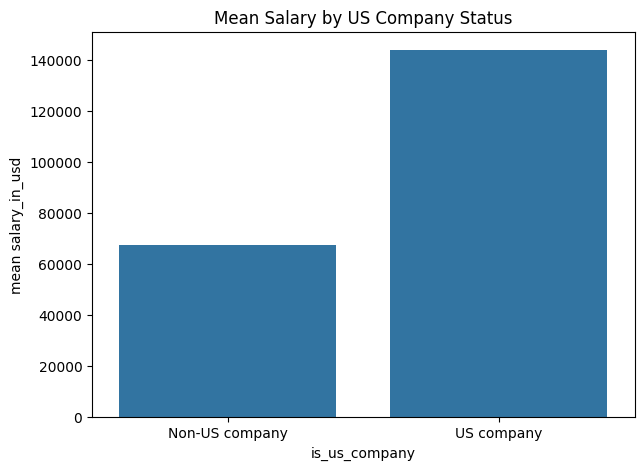

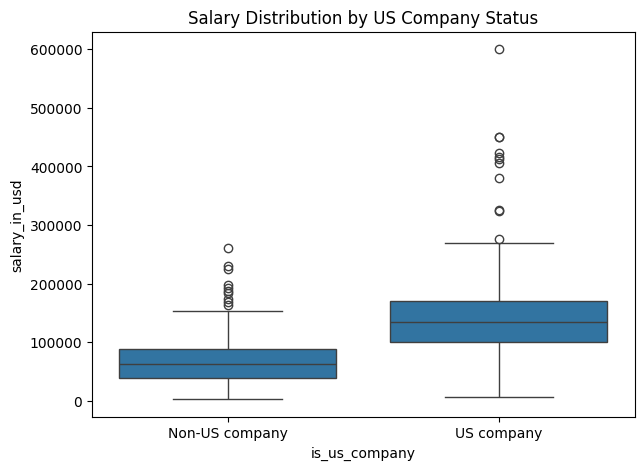

In [88]:
plt.figure(figsize=(7, 5))
sns.barplot(data=us_company_salary.reset_index(), x='is_us_company', y='mean')
plt.title('Mean Salary by US Company Status')
plt.xlabel('is_us_company')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_us_company', y='salary_in_usd')
plt.title('Salary Distribution by US Company Status')
plt.xlabel('is_us_company')
plt.ylabel('salary_in_usd')
plt.show()

In [89]:
#미국 거주 여부별 연봉

us_residence_salary = df.groupby('is_us_residence')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

display(us_residence_salary)

,count,mean,median,min,max
is_us_residence,,,,,
Non-US residence,275,67754.036364,62649.0,2859,260000
US residence,332,149194.117470,138475.0,25000,600000


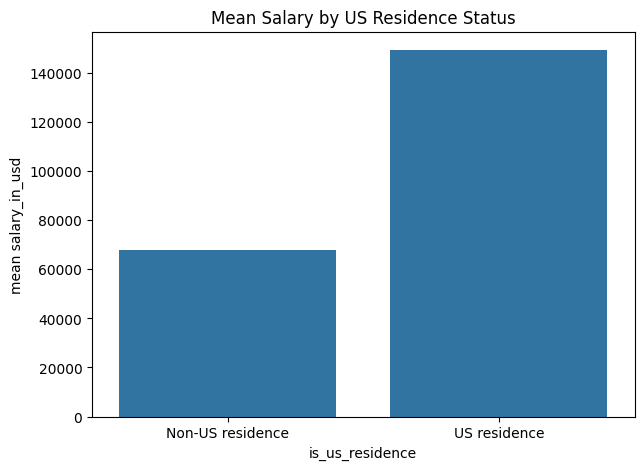

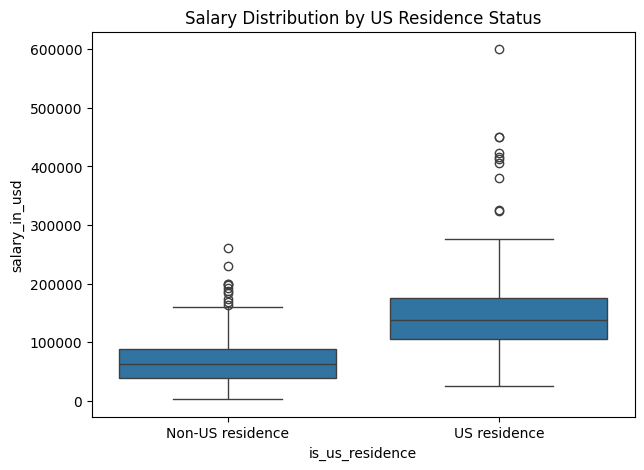

In [90]:
plt.figure(figsize=(7, 5))
sns.barplot(data=us_residence_salary.reset_index(), x='is_us_residence', y='mean')
plt.title('Mean Salary by US Residence Status')
plt.xlabel('is_us_residence')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_us_residence', y='salary_in_usd')
plt.title('Salary Distribution by US Residence Status')
plt.xlabel('is_us_residence')
plt.ylabel('salary_in_usd')
plt.show()

In [91]:
# 거주 국가와 회사 위치 일치 여부별 연봉

same_country_salary = df.groupby('same_country')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

display(same_country_salary)

,count,mean,median,min,max
same_country,,,,,
Different country,51,76758.352941,61467.0,5679,225000
Same country,556,115557.789568,105200.0,2859,600000


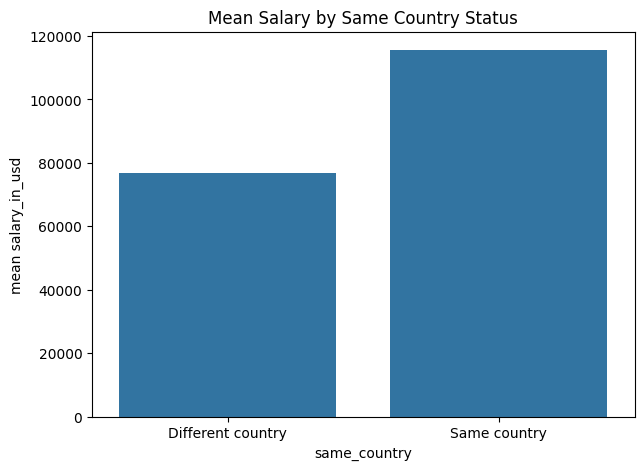

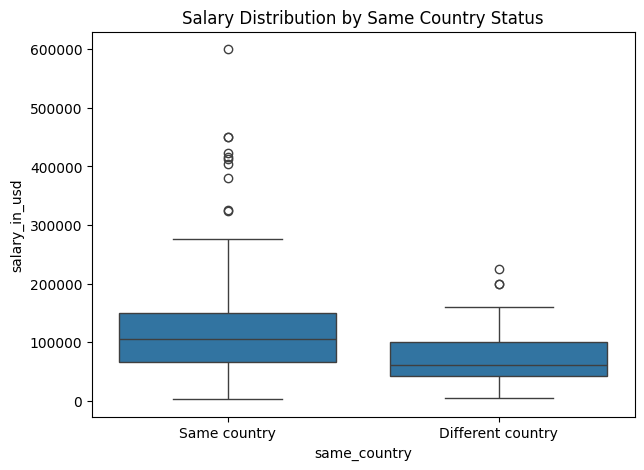

In [92]:
plt.figure(figsize=(7, 5))
sns.barplot(data=same_country_salary.reset_index(), x='same_country', y='mean')
plt.title('Mean Salary by Same Country Status')
plt.xlabel('same_country')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='same_country', y='salary_in_usd')
plt.title('Salary Distribution by Same Country Status')
plt.xlabel('same_country')
plt.ylabel('salary_in_usd')
plt.show()

In [93]:
#완전 원격근무 여부별 연봉

full_remote_salary = df.groupby('is_full_remote')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

display(full_remote_salary)

,count,mean,median,min,max
is_full_remote,,,,,
Full remote,381,122457.454068,115000.0,4000,600000
Not full remote,226,95170.429204,82636.0,2859,450000


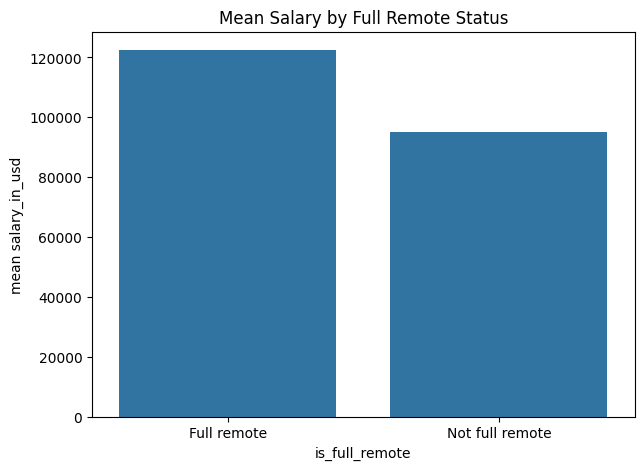

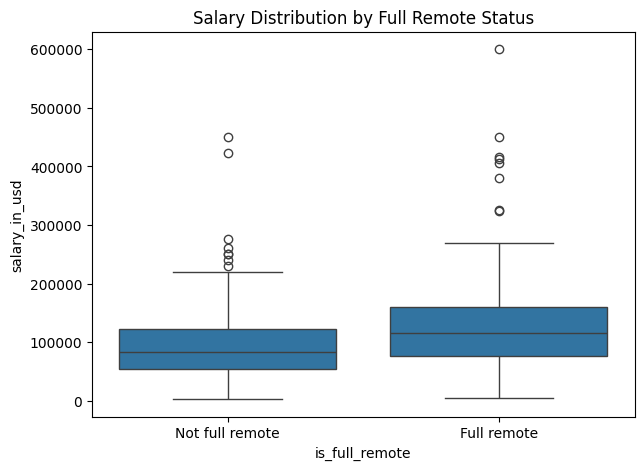

In [94]:
plt.figure(figsize=(7, 5))
sns.barplot(data=full_remote_salary.reset_index(), x='is_full_remote', y='mean')
plt.title('Mean Salary by Full Remote Status')
plt.xlabel('is_full_remote')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_full_remote', y='salary_in_usd')
plt.title('Salary Distribution by Full Remote Status')
plt.xlabel('is_full_remote')
plt.ylabel('salary_in_usd')
plt.show()

기본 변수 EDA 결과, 미국 회사와 미국 거주자의 비중이 높고, 원격근무 100% 그룹의 연봉이 높게 나타남

원본 컬럼만으로는 회사 위치 효과, 거주 국가 효과, 원격근무 효과를 비교하기 어려움

가설 분석을 위해 파생변수를 생성

- `is_us_company`: 회사 위치가 미국인지 여부
- `is_us_residence`: 직원 거주지가 미국인지 여부
- `same_country`: 직원 거주 국가와 회사 위치가 같은지 여부
- `is_full_remote`: 원격근무 비율이 100%인지 여부

- company_location에는 US, GB, CA, IN 등 국가가 많음
- 너무 많은 범주를 방지하기 위해 표본 개수가 많은 미국회사인 is_us_company를 만듦

# 가설 검정

가설 2 [직원 거주 국가보다 회사 위치가 연봉에 더 큰 영향을 줄 것이다.]

employee_residence는 직원이 사는 국가이고, company_location은 회사가 위치한 국가임

둘 중 어떤 기준이 연봉 차이를 더 잘 설명하는지?

In [95]:
#미국 거주 여부별 연봉

us_residence_salary = df.groupby('is_us_residence')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

display(us_residence_salary)

,count,mean,median,min,max
is_us_residence,,,,,
Non-US residence,275,67754.036364,62649.0,2859,260000
US residence,332,149194.117470,138475.0,25000,600000


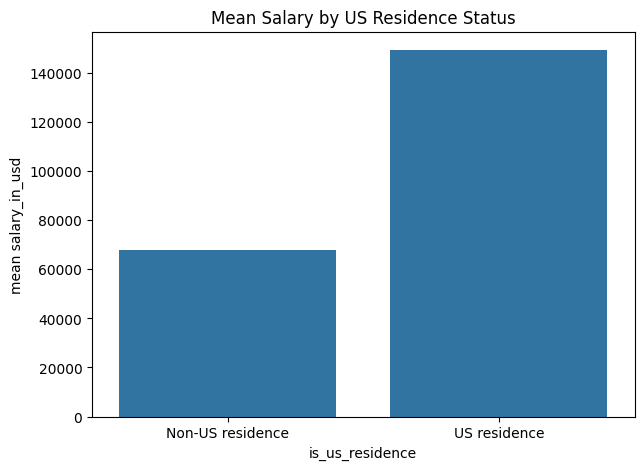

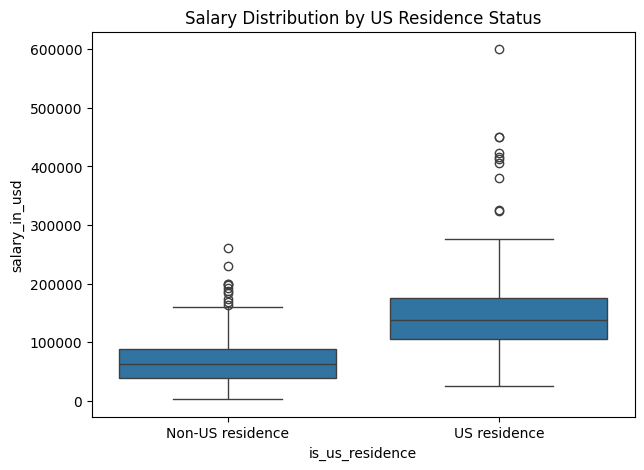

In [96]:
plt.figure(figsize=(7, 5))
sns.barplot(data=us_residence_salary.reset_index(), x='is_us_residence', y='mean')
plt.title('Mean Salary by US Residence Status')
plt.xlabel('is_us_residence')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_us_residence', y='salary_in_usd')
plt.title('Salary Distribution by US Residence Status')
plt.xlabel('is_us_residence')
plt.ylabel('salary_in_usd')
plt.show()

In [97]:
#미국 회사 여부별 연봉

us_company_salary = df.groupby('is_us_company')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

display(us_company_salary)

,count,mean,median,min,max
is_us_company,,,,,
Non-US company,252,67560.273810,62688.5,2859,260000
US company,355,144055.261972,135000.0,5679,600000


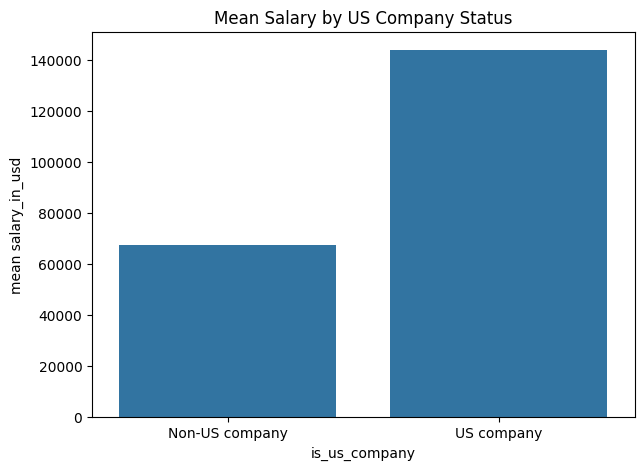

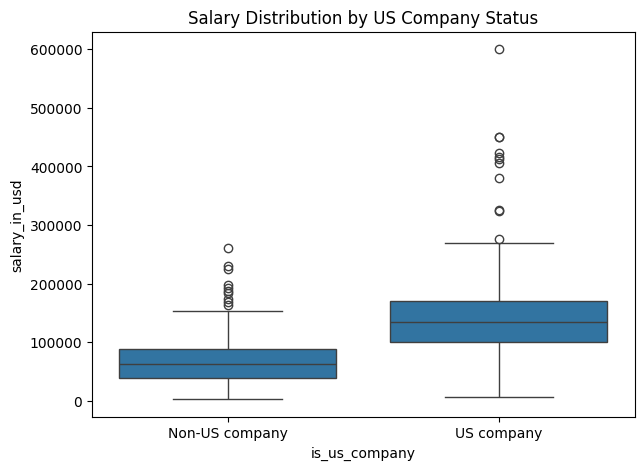

In [98]:
plt.figure(figsize=(7, 5))
sns.barplot(data=us_company_salary.reset_index(), x='is_us_company', y='mean')
plt.title('Mean Salary by US Company Status')
plt.xlabel('is_us_company')
plt.ylabel('mean salary_in_usd')
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_us_company', y='salary_in_usd')
plt.title('Salary Distribution by US Company Status')
plt.xlabel('is_us_company')
plt.ylabel('salary_in_usd')
plt.show()

In [99]:
#거주 국가와 회사 위치 조합 비교

residence_company = df.groupby(
    ['is_us_residence', 'is_us_company']
)['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
).reset_index().sort_values('mean', ascending=False)

display(residence_company)

,is_us_residence,is_us_company,count,mean,median,min,max
2,US residence,Non-US company,2,188500.000,188500.0,152000,225000
3,US residence,US company,330,148955.900,138175.0,25000,600000
1,Non-US residence,US company,25,79366.840,60000.0,5679,200000
0,Non-US residence,Non-US company,250,66592.756,62650.0,2859,260000


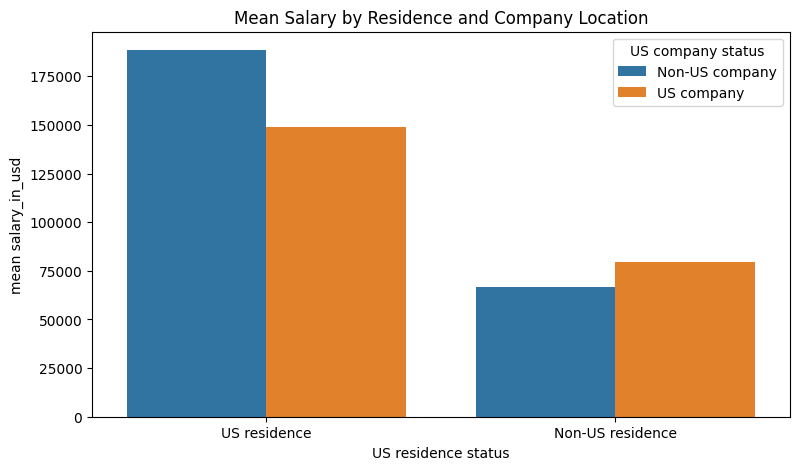

In [100]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=residence_company,
    x='is_us_residence',
    y='mean',
    hue='is_us_company'
)
plt.title('Mean Salary by Residence and Company Location')
plt.xlabel('US residence status')
plt.ylabel('mean salary_in_usd')
plt.legend(title='US company status')
plt.show()

미국 거주 여부와 미국 회사 여부를 조합하여 평균 연봉을 비교한 결과, 비미국 거주자 그룹에서는 미국 회사 소속자의 평균 연봉이 비미국 회사 소속자보다 높게 나타남
직원 거주 국가보다 회사 위치가 연봉에 영향을 줄 수 있다는 가설을 일부 지지

미국 거주자 그룹에서는 비미국 회사 소속자의 평균 연봉이 더 높게 나타났는데, 해당 조합의 표본 수가 적거나 일부 고연봉자의 영향으로 평균이 왜곡되었을 가능성 있음

평균뿐 아니라 count와 median을 함께 확인

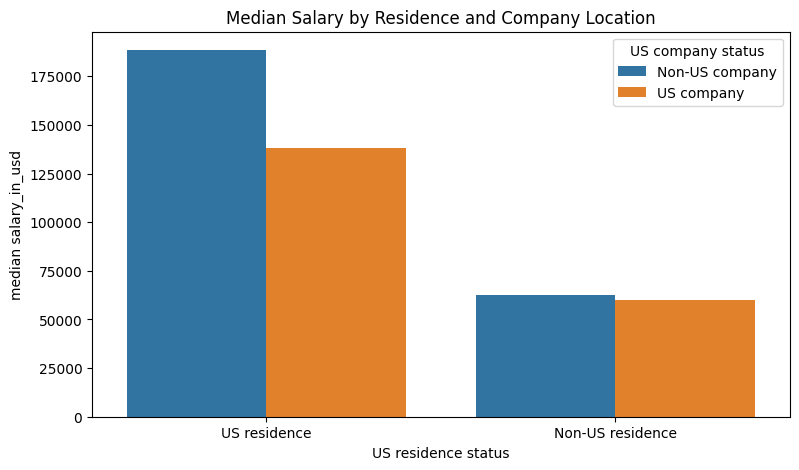

In [101]:
#중앙값 기준
plt.figure(figsize=(9, 5))

sns.barplot(
    data=residence_company,
    x='is_us_residence',
    y='median',
    hue='is_us_company'
)

plt.title('Median Salary by Residence and Company Location')
plt.xlabel('US residence status')
plt.ylabel('median salary_in_usd')
plt.legend(title='US company status')
plt.show()

US residence + Non-US company는 count가 2개뿐
전체 경향으로 해석하기 어려움!

---

표본 수가 충분한 조합
| 조합                                | count |
| --------------------------------- | ----: |
| US residence + US company         |   330 |
| Non-US residence + Non-US company |   250 |


US residence + US company

mean: 148,955.9
median: 138,175


Non-US residence + Non-US company

mean: 66,592.756
median: 62,650

- 미국 거주 + 미국 회사 조합은 비미국 거주 + 비미국 회사 조합보다 평균과 중앙값이 모두 훨씬 높음

- 데이터 전체에서 미국 중심 임금 수준이 강하게 나타난다는 뜻

Non-US residence + US company
vs
Non-US residence + Non-US company


---
| 조합                                | count |       mean | median |
| --------------------------------- | ----: | ---------: | -----: |
| Non-US residence + US company     |    25 |  79,366.84 | 60,000 |
| Non-US residence + Non-US company |   250 | 66,592.756 | 62,650 |


- 비미국 거주자 기준으로 보면 미국 회사 소속자의 평균은 높지만, 중앙값 기준에서는 뚜렷하게 높다고 보기 어려움
- 미국 회사 소속 비미국 거주자 중 일부 고연봉자가 평균을 끌어올렸을 가능성이 있음

- 직원 거주지와 회사 위치를 함께 비교한 결과, 미국 거주 + 미국 회사 조합의 연봉이 가장 안정적으로 높게 나타남.

- 비미국 거주자 중에서도 미국 회사 소속자의 평균 연봉이 더 높았지만, 중앙값 기준에서는 차이가 크지 않음.

- 회사 위치가 연봉에 영향을 줄 가능성은 있으나, 일부 조합의 표본 수가 적고 평균이 이상치에 영향을 받을 수 있어 가설은 일부 지지로 해석할 수 있음.

## ML

employee_residence와 company_location 중 어떤 변수가 salary_in_usd 예측에 더 도움이 되는가?

로 질문을 약간 바꿔서 머신러닝



원래라면

| 모델   | 사용하는 변수                  | 목적                   |
| ---- | ------------------------ | -------------------- |
| 모델 A | `employee_residence`만 사용 | 직원 거주 국가만으로 연봉 예측    |
| 모델 B | `company_location`만 사용   | 회사 위치만으로 연봉 예측       |
| 모델 C | 둘 다 사용                   | 두 변수를 함께 넣었을 때 성능 비교 |


사용 변수를 위와 같이 해야하지만 원본 국가 코드가 너무 많으므로 만든 파생변수로 비교
(이렇게 하면 발생하는 이점/문제점 등 생각해봐야함)

| 모델   | 변수                | 의미            |
| ---- | ----------------- | ------------- |
| 모델 D | `is_us_residence` | 미국 거주 여부만 사용  |
| 모델 E | `is_us_company`   | 미국 회사 여부만 사용  |
| 모델 F | 둘 다 사용            | 단순화된 위치 변수 비교 |



**MAE**
- 예측값과 실제값의 차이를 절댓값으로 계산한 뒤 평균낸 값

예) 모델이 평균적으로 몇 달러 정도 틀리는가?

MAE가 32,786이면 평균적으로 약 32,786달러 정도 예측 오차가 난다.

**RMSE**
- 예측 오차를 제곱해서 평균낸 뒤 다시 제곱근을 씌운 값
- MAE보다 큰 오차에 더 민감

예) 어떤 사람의 연봉을 크게 틀리면 RMSE가 많이 커짐
- RMSE가 낮을수록 좋은 모델

**R²**
- 모델이 타깃 변수인 salary_in_usd의 변동을 얼마나 설명하는지 나타내는 지표

예) R² = 0.4406이면 대략
이 모델이 연봉 변동의 약 44% 정도를 설명한다라고 해석

- R²가 높다고 무조건 좋은 모델은 아니고, 데이터 수나 과적합 가능성 확인

---


In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd

In [103]:
#모델 D: 미국 거주 여부만 사용

X_d = df[['is_us_residence']]
y = df['salary_in_usd']

# 범주형 변수를 숫자로 변환
X_d_encoded = pd.get_dummies(X_d, drop_first=True)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d_encoded,
    y,
    test_size=0.2,
    random_state=42
)

model_d = LinearRegression()
model_d.fit(X_train_d, y_train_d)

pred_d = model_d.predict(X_test_d)

mae_d = mean_absolute_error(y_test_d, pred_d)
rmse_d = np.sqrt(mean_squared_error(y_test_d, pred_d))
r2_d = r2_score(y_test_d, pred_d)

print("Model D: is_us_residence only")
print("MAE:", mae_d)
print("RMSE:", rmse_d)
print("R2:", r2_d)

Model D: is_us_residence only
MAE: 35392.91119865576
RMSE: 47727.555670049565
R2: 0.4056416295997417


In [104]:
#모델 E: 미국 회사 여부만 사용

X_e = df[['is_us_company']]
y = df['salary_in_usd']

X_e_encoded = pd.get_dummies(X_e, drop_first=True)

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_e_encoded,
    y,
    test_size=0.2,
    random_state=42
)

model_e = LinearRegression()
model_e.fit(X_train_e, y_train_e)

pred_e = model_e.predict(X_test_e)

mae_e = mean_absolute_error(y_test_e, pred_e)
rmse_e = np.sqrt(mean_squared_error(y_test_e, pred_e))
r2_e = r2_score(y_test_e, pred_e)

print("Model E: is_us_company only")
print("MAE:", mae_e)
print("RMSE:", rmse_e)
print("R2:", r2_e)

Model E: is_us_company only
MAE: 35270.31521720224
RMSE: 49117.51189782062
R2: 0.37051887027226904


In [105]:
#모델 F: 미국 거주 여부 + 미국 회사 여부 함께 사용

X_f = df[['is_us_residence', 'is_us_company']]
y = df['salary_in_usd']

X_f_encoded = pd.get_dummies(X_f, drop_first=True)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f_encoded,
    y,
    test_size=0.2,
    random_state=42
)

model_f = LinearRegression()
model_f.fit(X_train_f, y_train_f)

pred_f = model_f.predict(X_test_f)

mae_f = mean_absolute_error(y_test_f, pred_f)
rmse_f = np.sqrt(mean_squared_error(y_test_f, pred_f))
r2_f = r2_score(y_test_f, pred_f)

print("Model F: is_us_residence + is_us_company")
print("MAE:", mae_f)
print("RMSE:", rmse_f)
print("R2:", r2_f)

Model F: is_us_residence + is_us_company
MAE: 35402.3838021233
RMSE: 47729.17664683438
R2: 0.40560125638274014


In [106]:
#파생변수 기반 가설 2 모델 비교

hypothesis2_model_results = pd.DataFrame({
    'model': [
        'is_us_residence only',
        'is_us_company only',
        'is_us_residence + is_us_company'
    ],
    'MAE': [mae_d, mae_e, mae_f],
    'RMSE': [rmse_d, rmse_e, rmse_f],
    'R2': [r2_d, r2_e, r2_f]
})

display(hypothesis2_model_results.sort_values('RMSE'))

,model,MAE,RMSE,R2
0,is_us_residence only,35392.911199,47727.555670,0.405642
2,is_us_residence + is_us_company,35402.383802,47729.176647,0.405601
1,is_us_company only,35270.315217,49117.511898,0.370519


- 미국 거주 여부만으로도 상당 부분 설명되고,
미국 회사 여부를 추가해도 큰 개선이 없음

- 파생변수 기반 모델에서는 회사 위치보다 직원 거주 국가가 더 강하게 나타났거나, 두 변수가 서로 겹치는 정보가 많아 회사 위치의 추가 효과가 크지 않음. (왜냐하면 이 데이터에서 미국 거주자와 미국 회사 소속자가 많이 겹침)

- 미국 거주 여부, 미국 회사 여부 만 본 거 치고는 낮지 않은 R2 점수

- 미국 여부가 연봉 차이를 꽤 많이 설명한다고 볼 수도 있음


---

**원본 변수로 다시**
- 파생변수는 너무 단순화 되어 있음
- 세부 국가 차이를 모델이 반영할 수 있음

In [107]:
#모델 A 직원 거주 국가만 사용
X_a = df[['employee_residence']]
y = df['salary_in_usd']

X_a_encoded = pd.get_dummies(X_a, drop_first=True)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a_encoded,
    y,
    test_size=0.2,
    random_state=42
)

model_a = LinearRegression()
model_a.fit(X_train_a, y_train_a)

pred_a = model_a.predict(X_test_a)

mae_a = mean_absolute_error(y_test_a, pred_a)
rmse_a = np.sqrt(mean_squared_error(y_test_a, pred_a))
r2_a = r2_score(y_test_a, pred_a)

In [108]:
#모델 B 회사 위치만 사용
X_b = df[['company_location']]
y = df['salary_in_usd']

X_b_encoded = pd.get_dummies(X_b, drop_first=True)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b_encoded,
    y,
    test_size=0.2,
    random_state=42
)

model_b = LinearRegression()
model_b.fit(X_train_b, y_train_b)

pred_b = model_b.predict(X_test_b)

mae_b = mean_absolute_error(y_test_b, pred_b)
rmse_b = np.sqrt(mean_squared_error(y_test_b, pred_b))
r2_b = r2_score(y_test_b, pred_b)

In [109]:
#직원 거주 국가 + 회사 위치 같이 사용

X_c = df[['employee_residence', 'company_location']]
y = df['salary_in_usd']

X_c_encoded = pd.get_dummies(X_c, drop_first=True)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c_encoded,
    y,
    test_size=0.2,
    random_state=42
)

model_c = LinearRegression()
model_c.fit(X_train_c, y_train_c)

pred_c = model_c.predict(X_test_c)

mae_c = mean_absolute_error(y_test_c, pred_c)
rmse_c = np.sqrt(mean_squared_error(y_test_c, pred_c))
r2_c = r2_score(y_test_c, pred_c)

In [110]:
original_location_model_results = pd.DataFrame({
    'model': [
        'employee_residence only',
        'company_location only',
        'employee_residence + company_location'
    ],
    'MAE': [mae_a, mae_b, mae_c],
    'RMSE': [rmse_a, rmse_b, rmse_c],
    'R2': [r2_a, r2_b, r2_c]
})

display(original_location_model_results.sort_values('RMSE'))

,model,MAE,RMSE,R2
0,employee_residence only,32786.259083,46301.403954,0.440631
1,company_location only,34427.609507,49585.375555,0.358470
2,employee_residence + company_location,34886.596383,50122.928803,0.344485


| 이유        | 설명                                                                    |
| --------- | --------------------------------------------------------------------- |
| 변수 중복     | 미국 거주자와 미국 회사 소속자가 많이 겹치기 때문에 두 변수가 비슷한 정보를 담고 있을 수 있음                |
| 범주가 너무 많음 | `employee_residence`, `company_location`은 국가 코드가 많아 원-핫 인코딩 후 컬럼이 많아짐 |
| 표본 수 부족   | 특정 국가 조합은 데이터 수가 매우 적어 모델이 불안정하게 학습할 수 있음                             |


- 직원 거주 국가만으로도 연봉 차이의 약 44% 설명
- 회사 위치만 사용했을 때는 설명력이 약 36% 설명

- 현재 결과에서는 직원 거주 국가만 사용한 모델이 가장 좋음

가설 2 [직원 거주 국가보다 회사 위치가 연봉에 더 큰 영향을 줄 것이다.]

가설 2는 현재 모델 결과에서는 반대로 나옴

여기서 이제 회사위치, 거주국가 별 회귀계수 그래프화 해서 보고 어느정도의 영향력을 미치는지 파악

-->
해석할 때 회귀계수가 크다고 무조건 그 나라가 연봉을 높게 받는다는 것이 아닌것이 특정 국가의 데이터가 1~2개뿐인데 그 사람들이 고연봉이라면 계수가 크게 나올 수 있음을 주의 (데이터 수를 함께 고려해야 함)


아래와 같은 변수들의 관계를 히트맵을 이용해서 해석 할 수도 있음


| 관계                                          | 의미                 |
| ------------------------------------------- | ------------------ |
| `is_us_residence_num` ↔ `salary_in_usd`     | 미국 거주 여부와 연봉 관계    |
| `is_us_company_num` ↔ `salary_in_usd`       | 미국 회사 여부와 연봉 관계    |
| `is_us_residence_num` ↔ `is_us_company_num` | 두 변수가 얼마나 겹치는지     |
| `remote_ratio` ↔ `is_us_company_num`        | 원격근무와 미국 회사 여부의 관계 |
| `remote_ratio` ↔ `salary_in_usd`            | 원격근무와 연봉의 관계       |


---


**전체 모델링의 목적 : [연봉 예측 모델 만들기]**

가설 2, 3, 5의 변수만 사용하는 것이 아니라 여러 변수들을 함께 넣는다

features = [
    'work_year',
    'experience_level',
    'employment_type',
    'job_title',
    'is_us_residence',
    'remote_ratio',
    'is_us_company',
    'company_size'
]

target = 'salary_in_usd'

**확인할 것**
| 질문                                   | 확인 내용                                              |
| ------------------------------------ | -------------------------------------------------- |
| 연봉을 어느 정도 예측할 수 있는가?                 | RMSE, MAE, R²                                      |
| 어떤 모델이 가장 성능이 좋은가?                   | Linear Regression, Ridge, RandomForestRegressor 비교 |
| EDA에서 중요해 보였던 변수가 실제 모델에서도 중요한가?     | 회귀계수 또는 Feature Importance 확인                      |
| 원격근무, 회사 위치, 경력 수준 중 무엇이 더 중요해 보이는가? | 변수 영향 해석                                           |


**전체 흐름도**

1. 변수 EDA
2. 가설 설정
3. 가설별 EDA
4. 가설별 보조 모델링
5. 전체 연봉 예측 모델링
6. 모델 성능 비교
7. 변수 중요도 해석
8. 결론